In [28]:
from xgboost import XGBRegressor
import os
import glob
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [29]:
df_all = pd.read_csv("all_data.csv")
df_all

,bbox_x1,bbox_y1,bbox_x2,bbox_y2,conf,class,median_m,angular_z,imu_gyro_z,imu_acc_x,...,ratio_diff,log_bbox_width,log_bbox_height,log_bbox_area,log_ratio_w,log_ratio_h,log_ratio_mean,log_ratio_area,log_ratio_diag,source_file
0,406.343628,319.237488,422.137848,343.154999,0.750268,0,1.0610,0.000186,0.000000,-0.008978,...,0.363065,2.759644,3.174611,5.934255,-2.664320,-1.866272,-2.187712,-4.530519,-2.004881,preprocessed_SoldierFront100-110.csv
1,338.622772,320.997101,353.408875,344.326141,0.736244,0,1.0620,0.000186,0.000000,-0.008978,...,0.336509,2.693688,3.149699,5.843387,-2.598364,-1.841360,-2.149878,-4.439659,-1.967858,preprocessed_SoldierFront100-110.csv
2,406.425507,319.276794,422.063110,343.386627,0.748280,0,1.0610,0.000186,0.000000,0.043096,...,0.351301,2.749679,3.182620,5.932298,-2.654354,-1.874280,-2.190107,-4.528563,-2.007500,preprocessed_SoldierFront100-110.csv
3,338.809448,321.090179,353.351593,344.466187,0.730411,0,1.0610,0.000186,0.000000,0.043096,...,0.324800,2.677051,3.151710,5.828761,-2.581728,-1.843371,-2.145897,-4.425035,-1.964596,preprocessed_SoldierFront100-110.csv
4,406.428711,319.309479,422.181030,343.338165,0.748989,0,1.0610,0.000186,0.000000,0.043096,...,0.358266,2.756988,3.179248,5.936236,-2.661663,-1.870909,-2.190080,-4.532500,-2.007315,preprocessed_SoldierFront100-110.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,337.111603,316.819244,400.950653,345.951233,0.755896,1,1.0260,0.200513,0.177721,-0.122703,...,0.585312,4.156365,3.371837,7.528202,-2.488646,-2.177906,-2.321254,-4.666466,-2.419413,preprocessed_TankSide95-105.csv
646,615.525635,313.758240,639.000000,367.489532,0.528726,1,0.9575,0.200513,0.191556,-0.117316,...,1.169176,3.155909,3.983996,7.139905,-1.488198,-2.790057,-1.940734,-4.278203,-2.239803,preprocessed_TankSide95-105.csv
647,595.601685,313.960632,639.000000,364.689484,0.475336,1,0.9870,0.200513,0.191556,-0.117316,...,0.750565,3.770421,3.926495,7.696915,-2.102706,-2.732557,-2.368841,-4.835160,-2.369561,preprocessed_TankSide95-105.csv
648,588.698120,315.298706,639.000000,343.233093,0.722314,1,1.0280,-0.273218,0.208583,-0.129885,...,0.194655,3.918042,3.329858,7.247901,-2.250326,-2.135928,-2.191492,-4.386191,-2.220910,preprocessed_TankSide95-105.csv


In [30]:
from sklearn.ensemble import RandomForestRegressor

def rf_model(seed):
    return RandomForestRegressor(
        n_estimators=100,
        random_state=seed,
        n_jobs=-1
    )

def xg_model(seed):
    return XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=seed,
    n_jobs=-1
)


def evaluate_with_seeds(model_fn, X, y, seeds=range(10), test_size=0.2):
    maes, rmses, r2s = [], [], []

    for seed in seeds:
        # split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=seed
        )

        # 모델 생성 (seed마다 새로)
        model = model_fn(seed)

        # 학습
        model.fit(X_train, y_train)

        # 예측
        y_pred = model.predict(X_test)

        # metric 계산
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)

    # 평균 + 표준편차
    print("\n[RESULT]")
    print(f"MAE : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
    print(f"RMSE: {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")
    print(f"R2  : {np.mean(r2s):.4f} ± {np.std(r2s):.4f}")

    return


[RESULT]
MAE : 0.0386
RMSE: 0.0701
R2  : 0.9342


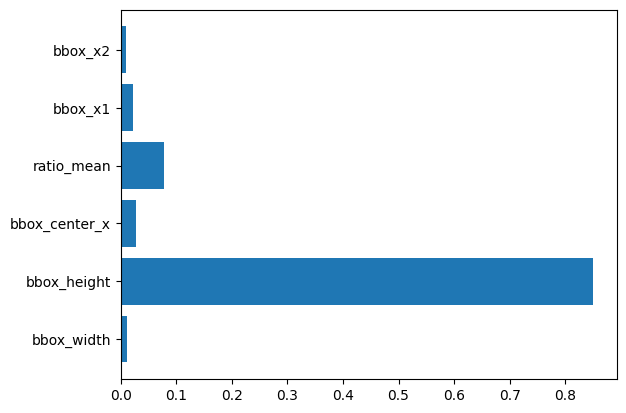


[RESULT]
MAE : 0.0379 ± 0.0034
RMSE: 0.0651 ± 0.0090
R2  : 0.9397 ± 0.0187

[RESULT]
MAE : 0.0391 ± 0.0034
RMSE: 0.0664 ± 0.0082
R2  : 0.9376 ± 0.0172


In [31]:
# target 변수 제외
# 데이터 전처리

feature_cols = [
    "bbox_width",
    "bbox_height",
    "bbox_center_x",
    "ratio_mean",  
    "bbox_x1",
    "bbox_x2",
]

X = df_all[feature_cols].copy()
y = df_all["median_m"].copy()


X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=43
)


X_train = pd.DataFrame(
    X_train,
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    X_test,
    columns=X_test.columns,
    index=X_test.index
)

rf = RandomForestRegressor(
        n_estimators=100,
        random_state=46,
        n_jobs=-1
    )
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n[RESULT]")
print(f"MAE : {np.mean(mae):.4f}")
print(f"RMSE: {np.mean(rmse):.4f}")
print(f"R2  : {np.mean(r2):.4f}")


importances = rf.feature_importances_
plt.barh(X_train.columns, importances)
plt.show()
evaluate_with_seeds(rf_model, X, y)
evaluate_with_seeds(xg_model, X, y)

In [5]:
def rf_model(seed):
    return RandomForestRegressor(
        n_estimators=100,
        random_state=seed,
        n_jobs=-1
    )

In [ ]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=46
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=44)

# 모델
rf = RandomForestRegressor(random_state=48, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "max_features": ["sqrt", None]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")

print(summary.head(10))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 500}
Best CV Score (MAE): 0.03895476944743141
Test MAE: 0.03450228282493929
Test RMSE: 0.056315118964440504
Test R2: 0.9515734810724433


In [18]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=46
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=44)

# 모델
rf = RandomForestRegressor(random_state=48, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "max_features": ["sqrt", None]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")

print(summary.head(10))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV Score (MAE): 0.039197029611185416
Test MAE: 0.03588885308886525
Test RMSE: 0.0642791274112226
Test R2: 0.9438323945161319
    max_depth max_features  n_estimators  mean_test_score  std_test_score  \
31       20.0         sqrt           200        -0.039197        0.006909   
1         NaN         sqrt           200        -0.039199        0.006904   
41       30.0         sqrt           200        -0.039199        0.006904   
32       20.0         sqrt           300        -0.039320        0.006987   
2         NaN         sqrt           300        -0.039322        0.006984   
42       30.0         sqrt           300        -0.039322        0.006984   
34       20.0         sqrt           500        -0.039392        0.006830   
4         NaN         sqrt           500        -0.039396        0.006826   
44       30.0         sqrt           50

In [20]:
summary

,max_depth,max_features,n_estimators,mean_test_score,std_test_score,rank_test_score
31,20.0,sqrt,200,-0.039197,0.006909,1
1,NaN,sqrt,200,-0.039199,0.006904,2
41,30.0,sqrt,200,-0.039199,0.006904,2
32,20.0,sqrt,300,-0.039320,0.006987,4
2,NaN,sqrt,300,-0.039322,0.006984,5
42,30.0,sqrt,300,-0.039322,0.006984,5
34,20.0,sqrt,500,-0.039392,0.006830,7
4,NaN,sqrt,500,-0.039396,0.006826,8
44,30.0,sqrt,500,-0.039396,0.006826,8
33,20.0,sqrt,400,-0.039410,0.006961,10


In [22]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=47
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=44)

# 모델
rf = RandomForestRegressor(random_state=50, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "max_features": ["sqrt", None]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")

print(summary.head(10))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}
Best CV Score (MAE): 0.038695996256812124
Test MAE: 0.037658180897888
Test RMSE: 0.06622006103844792
Test R2: 0.9427313284362241
    max_depth max_features  n_estimators  mean_test_score  std_test_score  \
2         NaN         sqrt           300        -0.038696        0.004482   
42       30.0         sqrt           300        -0.038696        0.004482   
32       20.0         sqrt           300        -0.038709        0.004466   
3         NaN         sqrt           400        -0.038753        0.004416   
43       30.0         sqrt           400        -0.038753        0.004416   
33       20.0         sqrt           400        -0.038757        0.004398   
4         NaN         sqrt           500        -0.038859        0.004507   
44       30.0         sqrt           500        -0.038859        0.004507   
34       20.0         sqrt           5

In [24]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=45
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=44)

# 모델
rf = RandomForestRegressor(random_state=45, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "max_features": ["sqrt", None]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")

print(summary.head(10))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'max_depth': None, 'max_features': None, 'n_estimators': 300}
Best CV Score (MAE): 0.03686608011084498
Test MAE: 0.03886116603067819
Test RMSE: 0.06666951074250436
Test R2: 0.9365181081005586
    max_depth max_features  n_estimators  mean_test_score  std_test_score  \
7         NaN         None           300        -0.036866        0.004281   
47       30.0         None           300        -0.036866        0.004281   
37       20.0         None           300        -0.036871        0.004287   
6         NaN         None           200        -0.036929        0.004275   
46       30.0         None           200        -0.036929        0.004275   
36       20.0         None           200        -0.036932        0.004276   
8         NaN         None           400        -0.036953        0.004205   
48       30.0         None           400        -0.036953        0.004205   
38       20.0         None           40

In [25]:
summary

,max_depth,max_features,n_estimators,mean_test_score,std_test_score,rank_test_score
7,NaN,None,300,-0.036866,0.004281,1
47,30.0,None,300,-0.036866,0.004281,1
37,20.0,None,300,-0.036871,0.004287,3
6,NaN,None,200,-0.036929,0.004275,4
46,30.0,None,200,-0.036929,0.004275,4
36,20.0,None,200,-0.036932,0.004276,6
8,NaN,None,400,-0.036953,0.004205,7
48,30.0,None,400,-0.036953,0.004205,8
38,20.0,None,400,-0.036958,0.004211,9
32,20.0,sqrt,300,-0.036969,0.003762,10


In [26]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=60
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=44)

# 모델
rf = RandomForestRegressor(random_state=90, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "max_features": ["sqrt", None]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'max_depth': None, 'max_features': None, 'n_estimators': 400}
Best CV Score (MAE): 0.037984745027812496
Test MAE: 0.036028626147799774
Test RMSE: 0.059157853235200446
Test R2: 0.9543271600057145


In [27]:
summary

,max_depth,max_features,n_estimators,mean_test_score,std_test_score,rank_test_score
8,NaN,None,400,-0.037985,0.003397,1
48,30.0,None,400,-0.037985,0.003397,1
49,30.0,None,500,-0.037989,0.003380,3
9,NaN,None,500,-0.037989,0.003380,3
39,20.0,None,500,-0.037989,0.003395,5
38,20.0,None,400,-0.037991,0.003415,6
43,30.0,sqrt,400,-0.038046,0.002293,7
3,NaN,sqrt,400,-0.038046,0.002293,8
33,20.0,sqrt,400,-0.038053,0.002304,9
4,NaN,sqrt,500,-0.038057,0.002262,10


In [ ]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=60
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=44)

# 모델
rf = RandomForestRegressor(random_state=90, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 20, 30],
    "max_features": ["sqrt", None],
}
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")
summary

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}
Best CV Score (MAE): 0.03806237508251896
Test MAE: 0.03696133379197232
Test RMSE: 0.0618059488289818
Test R2: 0.9501467171259256


In [33]:
summary

,max_depth,max_features,n_estimators,mean_test_score,std_test_score,rank_test_score
1,NaN,sqrt,300,-0.038062,0.002369,1
9,30.0,sqrt,300,-0.038062,0.002369,2
5,20.0,sqrt,300,-0.038080,0.002379,3
3,NaN,None,300,-0.038140,0.003378,4
11,30.0,None,300,-0.038140,0.003378,4
7,20.0,None,300,-0.038149,0.003394,6
0,NaN,sqrt,200,-0.038150,0.002264,7
8,30.0,sqrt,200,-0.038150,0.002264,7
4,20.0,sqrt,200,-0.038171,0.002291,9
2,NaN,None,200,-0.038279,0.003258,10


In [35]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=70
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=44)

# 모델
rf = RandomForestRegressor(random_state=80, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [300],
    "max_depth": [None, 20, 30],
    "max_features": ["sqrt"],
}
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")
summary

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}
Best CV Score (MAE): 0.03991124031822153
Test MAE: 0.03462821861841755
Test RMSE: 0.060588120505500054
Test R2: 0.9537603298268823


,max_depth,max_features,n_estimators,mean_test_score,std_test_score,rank_test_score
0,NaN,sqrt,300,-0.039911,0.005856,1
2,30.0,sqrt,300,-0.039911,0.005856,1
1,20.0,sqrt,300,-0.039915,0.005851,3


In [37]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=90
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=44)

# 모델
rf = RandomForestRegressor(random_state=80, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [300],
    "max_depth": [None, 20, 30],
    "max_features": ["sqrt"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")
summary

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (MAE): 0.03792163561134606
Test MAE: 0.04021737888957707
Test RMSE: 0.06938618532385822
Test R2: 0.9392777945354748


,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,mean_test_score,std_test_score,rank_test_score
12,20.0,sqrt,1,2,300,-0.037922,0.004843,1
0,NaN,sqrt,1,2,300,-0.037933,0.004796,2
24,30.0,sqrt,1,2,300,-0.037933,0.004796,2
13,20.0,sqrt,1,5,300,-0.039090,0.004631,4
1,NaN,sqrt,1,5,300,-0.039097,0.004634,5
25,30.0,sqrt,1,5,300,-0.039097,0.004634,6
3,NaN,sqrt,2,2,300,-0.039947,0.004639,7
27,30.0,sqrt,2,2,300,-0.039947,0.004639,7
15,20.0,sqrt,2,2,300,-0.039947,0.004639,9
16,20.0,sqrt,2,5,300,-0.040109,0.004461,10


In [38]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=70
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=44)

# 모델
rf = RandomForestRegressor(random_state=90, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [300],
    "max_depth": [None, 20, 30],
    "max_features": ["sqrt"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")
summary

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (MAE): 0.03998002552751715
Test MAE: 0.03399378651830894
Test RMSE: 0.05975553044053304
Test R2: 0.9550224310094955


,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,mean_test_score,std_test_score,rank_test_score
12,20.0,sqrt,1,2,300,-0.039980,0.005878,1
24,30.0,sqrt,1,2,300,-0.039985,0.005888,2
0,NaN,sqrt,1,2,300,-0.039985,0.005888,3
13,20.0,sqrt,1,5,300,-0.041457,0.005919,4
25,30.0,sqrt,1,5,300,-0.041457,0.005919,5
1,NaN,sqrt,1,5,300,-0.041457,0.005919,6
15,20.0,sqrt,2,2,300,-0.041853,0.005843,7
3,NaN,sqrt,2,2,300,-0.041853,0.005843,8
27,30.0,sqrt,2,2,300,-0.041853,0.005843,8
28,30.0,sqrt,2,5,300,-0.042306,0.005730,10


In [42]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=80
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=44)

# 모델
rf = RandomForestRegressor(random_state=10, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [300],
    "max_depth": [20],
    "max_features": ["sqrt"],
    "min_samples_split": [1, 2, 5, 10],
    "min_samples_leaf": [1]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")
summary

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/home/ubuntu/venvs/yolo_gpu/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
5 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/home/ubuntu/venvs/yolo_gpu/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/ubuntu/venvs/yolo_gpu/lib/python3.10/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
  File "/home/ubuntu/venvs/yolo_gpu/lib/python3.10/site-packages/sklearn/base.py", line 471, in _validate_params
    validate_parameter_constraint

Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (MAE): 0.0402468263434155
Test MAE: 0.03436131576281851
Test RMSE: 0.06559871061404611
Test R2: 0.938366137782


,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,mean_test_score,std_test_score,rank_test_score
1,20,sqrt,1,2,300,-0.040247,0.003083,1
2,20,sqrt,1,5,300,-0.041313,0.002881,2
3,20,sqrt,1,10,300,-0.044528,0.002533,3
0,20,sqrt,1,1,300,NaN,NaN,4


In [44]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=80
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=44)

# 모델
rf = RandomForestRegressor(random_state=10, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [300],
    "max_depth": [20],
    "max_features": ["sqrt"],
    "min_samples_split": [2],
    "min_samples_leaf": [1],
    "max_leaf_nodes": [None, 32, 64, 128, 256]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")
summary

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': 256, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (MAE): 0.03989054464478682
Test MAE: 0.033710777590744395
Test RMSE: 0.06528142046027842
Test R2: 0.9389609215301603


,max_depth,max_features,max_leaf_nodes,min_samples_leaf,min_samples_split,n_estimators,mean_test_score,std_test_score,rank_test_score
4,20,sqrt,256.0,1,2,300,-0.039891,0.002714,1
3,20,sqrt,128.0,1,2,300,-0.040063,0.002728,2
0,20,sqrt,NaN,1,2,300,-0.040247,0.003083,3
2,20,sqrt,64.0,1,2,300,-0.042168,0.002549,4
1,20,sqrt,32.0,1,2,300,-0.047788,0.002387,5


In [49]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=80
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=44)

# 모델
rf = RandomForestRegressor(random_state=10, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [300],
    "max_depth": [20],
    "max_features": ["sqrt"],
    "min_samples_split": [2],
    "min_samples_leaf": [1],
    "max_leaf_nodes": [256]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")
summary

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': 256, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (MAE): 0.03989054464478682
Test MAE: 0.0337107775907444
Test RMSE: 0.06528142046027842
Test R2: 0.9389609215301603


,max_depth,max_features,max_leaf_nodes,min_samples_leaf,min_samples_split,n_estimators,mean_test_score,std_test_score,rank_test_score
0,20,sqrt,256,1,2,300,-0.039891,0.002714,1


In [50]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=80
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=44)

# 모델
rf = RandomForestRegressor(random_state=10, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = [
    {
        "n_estimators": [300],
        "max_depth": [20],
        "max_features": ["sqrt"],
        "min_samples_split": [2],
        "min_samples_leaf": [1],
        "max_leaf_nodes": [256],
        "bootstrap": [True],
        "max_samples": [None, 0.7, 0.8, 0.9]
    },
    {
        "n_estimators": [300],
        "max_depth": [20],
        "max_features": ["sqrt"],
        "min_samples_split": [2],
        "min_samples_leaf": [1],
        "max_leaf_nodes": [256],
        "bootstrap": [False]
    }
]
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")
summary

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Params: {'bootstrap': False, 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': 256, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (MAE): 0.0378980599270047
Test MAE: 0.03236395266039185
Test RMSE: 0.06786378348185756
Test R2: 0.9340363143005632


,bootstrap,max_depth,max_features,max_leaf_nodes,max_samples,min_samples_leaf,min_samples_split,n_estimators,mean_test_score,std_test_score,rank_test_score
4,False,20,sqrt,256,NaN,1,2,300,-0.037898,0.003163,1
0,True,20,sqrt,256,NaN,1,2,300,-0.039891,0.002714,2
3,True,20,sqrt,256,0.9,1,2,300,-0.040369,0.002680,3
2,True,20,sqrt,256,0.8,1,2,300,-0.040790,0.002718,4
1,True,20,sqrt,256,0.7,1,2,300,-0.041613,0.002999,5


In [52]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=80
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=44)

# 모델
rf = RandomForestRegressor(random_state=10, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = [
    {
        "n_estimators": [300],
        "max_depth": [20],
        "max_features": ["sqrt"],
        "min_samples_split": [2],
        "min_samples_leaf": [1],
        "max_leaf_nodes": [256],
        "bootstrap": [False],
        "ccp_alpha": [0.0, 0.001, 0.005, 0.01]
    }
]
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")
summary

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Params: {'bootstrap': False, 'ccp_alpha': 0.0, 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': 256, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (MAE): 0.03789805992700469
Test MAE: 0.03236395266039184
Test RMSE: 0.06786378348185756
Test R2: 0.9340363143005632


,bootstrap,ccp_alpha,max_depth,max_features,max_leaf_nodes,min_samples_leaf,min_samples_split,n_estimators,mean_test_score,std_test_score,rank_test_score
0,False,0.000,20,sqrt,256,1,2,300,-0.037898,0.003163,1
1,False,0.001,20,sqrt,256,1,2,300,-0.067359,0.003661,2
2,False,0.005,20,sqrt,256,1,2,300,-0.089815,0.007455,3
3,False,0.010,20,sqrt,256,1,2,300,-0.102628,0.010282,4


In [55]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=7)

# 모델
rf = RandomForestRegressor(random_state=10, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = [
    {
        "n_estimators": [300],
        "max_depth": [20],
        "max_features": ["sqrt"],
        "min_samples_split": [2],
        "min_samples_leaf": [1],
        "max_leaf_nodes": [256],
        "bootstrap": [False],
        "ccp_alpha": [0.0],
        "criterion": ["squared_error", "absolute_error"]
    }
]
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")
summary

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best Params: {'bootstrap': False, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': 256, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (MAE): 0.03540162357165775
Test MAE: 0.03638102590826924
Test RMSE: 0.06375159294968442
Test R2: 0.9459891475350719


,bootstrap,ccp_alpha,criterion,max_depth,max_features,max_leaf_nodes,min_samples_leaf,min_samples_split,n_estimators,mean_test_score,std_test_score,rank_test_score
0,False,0.0,squared_error,20,sqrt,256,1,2,300,-0.035402,0.005992,1
1,False,0.0,absolute_error,20,sqrt,256,1,2,300,-0.035482,0.005908,2


In [ ]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=1)

# 모델
rf = RandomForestRegressor(random_state=10, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = [
    {
        "n_estimators": [300],
        "max_depth": [20],
        "max_features": ["sqrt"],
        "min_samples_split": [2],
        "min_samples_leaf": [1],
        "max_leaf_nodes": [256],
        "bootstrap": [False],
        "ccp_alpha": [0.0],
        "criterion": ["squared_error", "absolute_error"],
        "min_impurity_decrease": [0.0]
    }
]
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")
summary

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'bootstrap': False, 'ccp_alpha': 0.0, 'criterion': 'absolute_error', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': 256, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (MAE): 0.037911961411035325
Test MAE: 0.03367262721619534
Test RMSE: 0.0674591776676056
Test R2: 0.9332886113643881


,bootstrap,ccp_alpha,criterion,max_depth,max_features,max_leaf_nodes,min_impurity_decrease,min_samples_leaf,min_samples_split,n_estimators,mean_test_score,std_test_score,rank_test_score
3,False,0.0,absolute_error,20,sqrt,256,0.000,1,2,300,-0.037912,0.001532,1
0,False,0.0,squared_error,20,sqrt,256,0.000,1,2,300,-0.038522,0.001582,2
4,False,0.0,absolute_error,20,sqrt,256,0.001,1,2,300,-0.049749,0.003714,3
1,False,0.0,squared_error,20,sqrt,256,0.001,1,2,300,-0.070483,0.003631,4
5,False,0.0,absolute_error,20,sqrt,256,0.010,1,2,300,-0.079053,0.004462,5
2,False,0.0,squared_error,20,sqrt,256,0.010,1,2,300,-0.118070,0.007023,6


In [59]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=1)

# 모델
rf = RandomForestRegressor(random_state=10, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = [
    {
        "n_estimators": [300],
        "max_depth": [20],
        "max_features": ["sqrt"],
        "min_samples_split": [2],
        "min_samples_leaf": [1],
        "max_leaf_nodes": [256],
        "bootstrap": [False],
        "ccp_alpha": [0.0],
        "criterion": ["squared_error", "absolute_error"],
        "min_impurity_decrease": [0.0]
    }
]
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")
summary

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best Params: {'bootstrap': False, 'ccp_alpha': 0.0, 'criterion': 'absolute_error', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': 256, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (MAE): 0.037911961411035325
Test MAE: 0.03367262721619534
Test RMSE: 0.0674591776676056
Test R2: 0.9332886113643881


,bootstrap,ccp_alpha,criterion,max_depth,max_features,max_leaf_nodes,min_impurity_decrease,min_samples_leaf,min_samples_split,n_estimators,mean_test_score,std_test_score,rank_test_score
1,False,0.0,absolute_error,20,sqrt,256,0.0,1,2,300,-0.037912,0.001532,1
0,False,0.0,squared_error,20,sqrt,256,0.0,1,2,300,-0.038522,0.001582,2


In [ ]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=2)

# 모델
rf = RandomForestRegressor(random_state=10, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = [
    {
        "n_estimators": [300],
        "max_depth": [20],
        "max_features": ["sqrt"],
        "min_samples_split": [2],
        "min_samples_leaf": [1],
        "max_leaf_nodes": [256],
        "bootstrap": [False],
        "ccp_alpha": [0.0],
        "criterion": ["absolute_error"],
        "min_impurity_decrease": [0.0]
    }
]
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")
summary

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best Params: {'bootstrap': False, 'ccp_alpha': 0.0, 'criterion': 'absolute_error', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': 256, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (MAE): 0.03642742421432188
Test MAE: 0.04227550844206267
Test RMSE: 0.08688964740940483
Test R2: 0.8916991373698159


,bootstrap,ccp_alpha,criterion,max_depth,max_features,max_leaf_nodes,min_impurity_decrease,min_samples_leaf,min_samples_split,n_estimators,mean_test_score,std_test_score,rank_test_score
1,False,0.0,absolute_error,20,sqrt,256,0.0,1,2,300,-0.036427,0.006426,1
0,False,0.0,squared_error,20,sqrt,256,0.0,1,2,300,-0.037811,0.006736,2



[RESULT]
MAE : 0.0000
RMSE: 0.0243
R2  : 0.9919


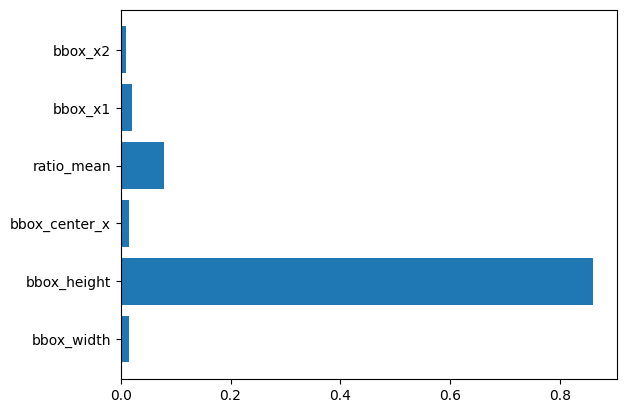


[RESULT]
MAE : 0.0379 ± 0.0034
RMSE: 0.0651 ± 0.0090
R2  : 0.9397 ± 0.0187

[RESULT]
MAE : 0.0391 ± 0.0034
RMSE: 0.0664 ± 0.0082
R2  : 0.9376 ± 0.0172


In [63]:
# target 변수 제외
# 데이터 전처리

feature_cols = [
    "bbox_width",
    "bbox_height",
    "bbox_center_x",
    "ratio_mean",  
    "bbox_x1",
    "bbox_x2",
]

X = df_all[feature_cols].copy()
y = df_all["median_m"].copy()


X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]



X = pd.DataFrame(
    X,
    columns=X.columns,
    index=X.index
)



rf = RandomForestRegressor(
        n_estimators=100,
        random_state=46,
        n_jobs=-1
    )
rf.fit(X, y)
y_pred = rf.predict(X)

mae = mean_absolute_error(y, y)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("\n[RESULT]")
print(f"MAE : {np.mean(mae):.4f}")
print(f"RMSE: {np.mean(rmse):.4f}")
print(f"R2  : {np.mean(r2):.4f}")


importances = rf.feature_importances_
plt.barh(X_train.columns, importances)
plt.show()
evaluate_with_seeds(rf_model, X, y)
evaluate_with_seeds(xg_model, X, y)

In [65]:
import pickle
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

df_all = pd.read_csv("all_data.csv")

feature_cols = [
    "bbox_width",
    "bbox_height",
    "bbox_center_x",
    "ratio_mean",
    "bbox_x1",
    "bbox_x2",
]

X = df_all[feature_cols].copy()
y = df_all["median_m"].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
    max_leaf_nodes=256,
    bootstrap=False,
    ccp_alpha=0.0,
    criterion="absolute_error",
    min_impurity_decrease=0.0,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("rf_feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("저장 완료")

저장 완료
